# GRU Neural Network for Insurance Claims Reserving

This notebook implements a Gated Recurrent Unit (GRU) neural network for predicting ultimate insurance claim amounts. The model processes sequential payment data to learn temporal patterns in claim development. This version processes data in a triangular format, with "3D" input of claims history to predict "2D" output of future claims history. 

## Overview
- **Objective**: Predict ultimate claim amounts using payment history
- **Data**: 
   * **X**: Entire claims history with features summarised by month, as padded sequence. 
   * **y**: all future payments, multi-output by month 
- **Model**: GRU with log-link activation for positive predictions
- **Features**: Temporal claim development data (occurrence time, development period, payment amounts, etc.). More features are available in source data than are used, but kept consistent with other notebooks for comparability (e.g. no outstanding).
- **Evaluation**: Actual vs Expected plots, QQ plots, and model interpretability via SHAP

## Import Libraries

We import essential libraries for data processing, neural networks, and visualization.

In addition we import a number of custom functions from the `utils` folder, developed for this notebook but stored separately to simplify this flow and presentation.


In [1]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import time
from datetime import datetime

# PyTorch imports

from torch.utils.tensorboard import SummaryWriter

# Scikit-learn imports
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline


# Local imports
from utils.config import ExperimentConfig, load_config_from_yaml
from utils.neural_networks import TabularNetRegressor, BasicLogGRU, ColumnKeeper, Make3D

from utils.data_engineering import load_data, process_data_grouped_triangular, create_train_test_datasets_seq_3D, make_claim_sampler
from utils.tensorboard import generate_enhanced_tensorboard_outputs, create_actual_vs_expected_plot

from utils.excel import save_df_to_excel

/Users/jacky/GitRepos/MLR_working_party/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration Setup

We configure the experiment settings, including model parameters, training settings, and output options.

Our configuration is read a config file in the utils folder.

In [2]:
# Load from YAML file
config = load_config_from_yaml('configs/GRU_triangular_config.yaml')

# Set pandas display options
pd.options.display.float_format = '{:,.2f}'.format

# Enable inline plotting for Jupyter notebooks
%matplotlib inline

SEED =  config['training'].seed # 42 
rng = np.random.default_rng(SEED) 

# Create timestamp for logging
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_name = f"GRU_experiment_triangular_{timestamp}"  # Customize as needed

# Initialize TensorBoard writer
writer = SummaryWriter(log_dir=f"runs/{run_name}")
log_filename = f"logs/{run_name}.xlsx"

print(f"Experiment timestamp: {timestamp}")
print(f"Output file: {log_filename}")

# Save excel data. Set this to True to better understand the data structure.
save_excel_data = config["save_excel"]

Experiment timestamp: 20260329_223436
Output file: logs/GRU_experiment_triangular_20260329_223436.xlsx


## Data Loading and Processing

The dataset used is SPLICE (Synthetic Paid Loss and Incurred Cost Experience), which is based on the R data simulation package SynthETIC ([Synthetic](https://cran.rstudio.com/web/packages/SynthETIC/index.html)). This is an interesting solution because is possible generate claims with some specific features.
Here a full description of the mentioned R package ([SynthETIC intro](https://institute-and-faculty-of-actuaries.github.io/mlr-blog/post/data/synthetic/)).

We load the raw insurance claims data and process it for neural network training. This includes:
- Loading raw data from CSV
- Feature engineering (development periods, payment indicators, etc.)
- Creating train/test splits based on date cutoff

In [3]:
# Load original data
dat_orig = load_data(config)
print(f"Original data shape: {dat_orig.shape}")
print(f"Original data columns: {list(dat_orig.columns)}")

# Save original data to Excel
if save_excel_data:
    save_df_to_excel(dat_orig, df_name="Original Data", filename=log_filename, mode='w')
dat_orig.head()

Original data shape: (19322, 13)
Original data columns: ['Unnamed: 0', 'claim_no', 'pmt_no', 'occurrence_period', 'occurrence_time', 'claim_size', 'notidel', 'setldel', 'payment_time', 'payment_period', 'payment_size', 'payment_inflated', 'payment_delay']


,Unnamed: 0,claim_no,pmt_no,occurrence_period,occurrence_time,claim_size,notidel,setldel,payment_time,payment_period,payment_size,payment_inflated,payment_delay
0,1,1,1,1,0.73,"232,310.09",0.66,23.21,5.33,6,"13,226.34","13,226.34",3.93
1,2,1,2,1,0.73,"232,310.09",0.66,23.21,10.09,11,"15,685.86","15,685.86",4.76
2,3,1,3,1,0.73,"232,310.09",0.66,23.21,18.02,19,"14,643.28","14,643.28",7.93
3,4,1,4,1,0.73,"232,310.09",0.66,23.21,22.82,23,"170,041.89","170,041.89",4.79
4,5,1,5,1,0.73,"232,310.09",0.66,23.21,24.61,25,"18,712.71","18,712.71",1.79




Processing code for this dataset (credit Davide, Nigel) has been put into the function 'process_data_grouped_triangular' part of the utils functions. It's not a particularly elegant solution but represent a half-way house towards standardised data processing functions. 

The function processes the input dataset to generate 40 development periods, 40 occurrence periods and around 3,600 claims. The data is converted to a time series with one record per time period (even if multiple or no claims transactions). Inspired from the MLWP tutorial here: http://institute-and-faculty-of-actuaries.github.io/mlr-blog/post/research/chain_ladder_to_individual_mdn/#introduction

We should note that, in a departure from the original notebook, incurred and outstanding data features are not used in this analysis. This is a deliberate choice to help compare these outputs to Sarah's work using GRUs that used paid datasets only. As it turns out, Sarah's GRU approach is deliberately structurally different and so the use of paid data only in this notebook is not sufficient to enable the direct comparison of approaches. 

This is likely too much detail for now. However the interested reader may observe that omission of incurred and outstanding features do result in slightly poorer model performance which can be seen by comparing QQ plots and oher exhibits from this notebook to the original. 


In [4]:
# Process data (feature engineering, filtering, etc.)
dat = process_data_grouped_triangular(config, dat_orig)
print(f"Processed data shape: {dat.shape}")
print(f"New columns added: {set(dat.columns) - set(dat_orig.columns)}")

# Save processed data to Excel
if save_excel_data:
    save_df_to_excel(dat, df_name="Processed Data", filename=log_filename, mode='a')

Processed data shape: (142841, 25)
New columns added: {'payment_to_prior_period', 'payment_period_as_at', 'payment_size_cumulative', 'log1_payment_to_prior_period', 'has_payment_to_prior_period', 'backdate_periods', 'occurrence_date', 'log1_cumulative_payment_to_prior_period', 'payment_date', 'cv_ind', 'payment_count_to_prior_period', 'train_ind', 'is_settled', 'data_as_at_development_period'}


/Users/jacky/GitRepos/MLR_working_party/02_code/utils/data_engineering.py:198: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dat['occurrence_date'] = pd.to_datetime(dat['occurrence_date']).dt.to_period('Q')
/Users/jacky/GitRepos/MLR_working_party/02_code/utils/data_engineering.py:199: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dat['payment_date'] = pd.to_datetime(dat['payment_date']).dt.to_period('Q')


## Train/Test Split Creation

We create training and test datasets:
- **Training**: Transactions before the cutoff date
- **Testing**: All transactions including transactions after the cutoff date

In [5]:
# Create train/test datasets
w_train, x_train, y_train, w_test, x_test, y_test = create_train_test_datasets_seq_3D(dat, config, epsilon=1e-6)

print(f"Training features shape: {x_train.shape}")
print(f"Training targets shape: {y_train.shape}")
print(f"Test features shape: {x_test.shape}")
print(f"Test targets shape: {y_test.shape}")

# Save datasets to Excel
if save_excel_data:
    save_df_to_excel(w_train, df_name="w_train", filename=log_filename, mode='a')
    save_df_to_excel(x_train, df_name="x_train", filename=log_filename, mode='a')
    save_df_to_excel(y_train, df_name="y_train", filename=log_filename, mode='a')

    save_df_to_excel(w_test, df_name="w_test", filename=log_filename, mode='a')
    save_df_to_excel(x_test, df_name="x_test", filename=log_filename, mode='a')
    save_df_to_excel(y_test, df_name="y_test", filename=log_filename, mode='a')

Training features shape: (72757, 8)
Training targets shape: (72757, 41)
Test features shape: (142841, 8)
Test targets shape: (142841, 41)


In [6]:
# Extract configuration values for model setup
features = config['data'].features
data_cols = config['data'].data_cols
youtput = config['data'].output_field

# Print dataset info
nclms = x_train['claim_no'].nunique()
nfeatures = len(features)

print(f"Number of unique claims in training: {nclms}")
print(f"Number of features: {nfeatures}")
print(f"Features: {features}")
print(f"Target variable: {youtput}")

Number of unique claims in training: 3571
Number of features: 7
Features: ['notidel', 'occurrence_time', 'development_period', 'payment_period', 'has_payment_to_prior_period', 'log1_payment_to_prior_period', 'payment_count_to_prior_period']
Target variable: payment_size


## Model Pipeline Setup


To manage the significantly expanded dataset resulting from our "backdating" augmentation, we implement a dynamic sampling strategy for model training. This involves a custom claim_sampler function, which, for each training epoch or batch, randomly selects just one historical snapshot for every unique (claim_no, development_period) combination. This approach efficiently utilizes the rich, augmented data by exposing the model to diverse temporal perspectives, thereby enhancing generalization and optimizing computational resources during the learning process.

In [7]:
# Sampling to reduce increase in batch size due to data augmentation
claim_sampler = make_claim_sampler(y_train)


We create a scikit-learn pipeline that:
1. **ColumnKeeper**: Selects relevant columns
2. **MinMaxScaler**: Normalizes features to [0,1] range (critical for neural networks)
3. **Make3D**: Converts tabular data to 3D tensors for GRU processing
4. **TabularNetRegressor**: Wraps the GRU model with training logic

In [8]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        # Scale 0-1, but preserve development_period for the Mark3D logic
        ('scale', MinMaxScaler(), 
         [x for x in features if x != "development_period"])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")

model_NN = Pipeline(
    steps=[
        ("keep", ColumnKeeper(data_cols)),   
        ('zero_to_one', preprocessor),       # Important! Standardize deep learning inputs.
        ('3Dtensor', Make3D(features, full_history=True, config=config)),  # Make 3D also scales development_period
        ("model", TabularNetRegressor(
            BasicLogGRU, 
            n_hidden=config['model'].n_hidden, 
            device=config['model'].device,
            max_lr=config['model'].max_lr,
            dropout=config['model'].dropout,
            keep_best_model=config['model'].keep_best_model,
            batch_norm=config['model'].batch_norm,
            clip_value=config['model'].clip_value,
            l1_penalty=config['model'].l1_penalty,
            weight_decay=config['model'].weight_decay,
            max_iter=config['training'].nn_iter,
            batch_function=claim_sampler if config['training'].use_batching_logic else None,                
            rebatch_every_iter=config['training'].rebatch_every_iter,  # takes time to resample so iterate this many epochs per resample,            
            enable_shap=config['training'].enable_shap,
            shap_log_frequency=config['tensorboard'].shap_log_frequency,
            seed=SEED,
            config=config
        ))
    ]
)

print("Model pipeline created successfully")
print(f"Hidden units: {config['model'].n_hidden}")
print(f"Training iterations: {config['training'].nn_iter}")

Model pipeline created successfully
Hidden units: 64
Training iterations: 101


In [9]:
# Model initial parameters
model_NN.named_steps["model"]

,module,<class 'utils....BasicLogGRU'>
,criterion,<class 'torch...issonNLLLoss'>
,max_iter,101
,max_lr,0.1
,keep_best_model,False
,batch_function,None
,rebatch_every_iter,100
,n_hidden,64
,l1_penalty,0.0
,l1_applies_params,"['linear.weight', 'hidden.weight']"
,weight_decay,0.0


## Model Training

We train the GRU model on the sequential payment data. The model learns to predict ultimate claim amounts from partial payment histories.



In [10]:
def train_model(model, w_train, x_train, y_train, config: ExperimentConfig):
    """
    Train the neural network model with timing.
    
    Args:
        model: The model pipeline to train
        x_train: Training features
        y_train: Training targets
        config: Experiment configuration
        
    Returns:
        Trained model and elapsed time
    """
    print("Starting model training...")
    start_time = time.time()
    
    model.fit(
        x_train, 
        y_train.drop(columns=["claim_no", "development_period"]), 
        model__sample_weight=w_train.drop(columns=["claim_no", "development_period"])
    )
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training completed. Execution time: {elapsed_time:.2f} seconds")
    
    return model, elapsed_time
  
# Train the model
trained_model, training_time = train_model(
    model_NN,
    w_train,
    x_train,
    y_train,
    config)

Starting model training...
Epoch: 0 Train RMSE: 26762.193359375 Train Loss: -40432.0390625
Epoch: 10 Train RMSE: 26754.33203125 Train Loss: -40454.171875
Epoch: 20 Train RMSE: 26747.228515625 Train Loss: -40377.84375
Epoch: 30 Train RMSE: 27157.44140625 Train Loss: -37343.56640625
Epoch: 40 Train RMSE: 26790.640625 Train Loss: -39610.96484375
Epoch: 50 Train RMSE: 26718.87890625 Train Loss: -40405.28125
Epoch: 60 Train RMSE: 26928.88671875 Train Loss: -40639.0
Epoch: 70 Train RMSE: 26673.783203125 Train Loss: -40746.546875
Epoch: 80 Train RMSE: 28784.357421875 Train Loss: -40772.37109375
Epoch: 90 Train RMSE: 32841.3125 Train Loss: -40779.1875
Epoch: 100 Train RMSE: 34892.99609375 Train Loss: -40780.375
Training completed. Execution time: 106.38 seconds


## Training Results and SHAP Analysis

After training, we generate predictions and SHAP explanations to understand feature importance. SHAP values show how each feature contributes to individual predictions.

To observe the tensorboard logs, run the following command in your terminal:

`tensorboard --logdir=./02_code/runs/`

In [11]:
# Generate raw predictions
y_pred = trained_model.predict(x_train)

In [12]:
# Generate enhanced outputs including SHAP analysis
# comment out for now, it seems to take a while
if config["training"].enable_shap:
    train_pred = generate_enhanced_tensorboard_outputs(
        trained_model, 
        x_train.assign(claim_size=y_train.filter(like="future_payment").sum(axis=1)), 
        config, 
        writer)

    if save_excel_data:
        save_df_to_excel(train_pred, df_name="pred_train", filename=log_filename, mode='a')
        save_df_to_excel(pd.DataFrame(y_pred, columns=['prediction']), df_name="y_pred_train", filename=log_filename, mode='a')

    print(f"Training predictions generated for {len(train_pred)} records")
    print(f"Mean predicted claim amount: ${train_pred['pred_claims'].mean():,.2f}")
    print(f"Mean actual claim amount: ${train_pred[youtput].mean():,.2f}")

# Test set claim projections
The model predicts all future payments of a claim so we can base our test set predictions using `y_pred`. We just need to compare to a test set containing only the active claims as at the latest diagonal. The model in the current format only predicts IBNER. 

In [13]:
# Match to training data and filter for latest diagonal 
youtput = "predicted_" + config["data"].output_field

pred_df = (
    pd.wide_to_long((
        pd.concat([
            x_train.reset_index(), 
            pd.DataFrame(y_pred, columns=[f"{youtput}{x}" for x in range(1, y_pred.shape[1]+1)])], axis='columns')
        .loc[lambda df: df.payment_period == config["data"].cutoff]
    ), stubnames=f"{youtput}", i=x_train.columns.to_list(), j="payment_delay")
    .reset_index()
    .assign(
        development_period=lambda df: np.minimum(config["data"].maxdev - 1, df.development_period + df.payment_delay),
        payment_period    =lambda df: (df.payment_period + df.payment_delay)
    )
    .loc[:, ["claim_no", "development_period", "payment_period", youtput]]
    .groupby(["claim_no", "development_period"])
    .agg({
        f"{youtput}": "sum",
        "payment_period": "min"
    })
    .reset_index()
)
# pred_df

# Data structure - in more detail:
Pull out an example claim number, `2105`. The records in the SPLICE dataset are as follows, with some records split across train and test. 

In [14]:
SAMPLE_NO = 2105

In [15]:
dat.loc[dat.claim_no==SAMPLE_NO]

,claim_no,occurrence_period,occurrence_time,noti_period,notidel,settle_period,development_period,payment_period,is_settled,occurrence_date,...,payment_to_prior_period,has_payment_to_prior_period,log1_payment_to_prior_period,log1_cumulative_payment_to_prior_period,payment_count_to_prior_period,data_as_at_development_period,backdate_periods,payment_period_as_at,train_ind,cv_ind
84160,2105,23,22.50,23,0.01,39,0,23,False,2005Q3,...,0.00,0,0.00,0.00,0.00,0,0,23,True,3
84161,2105,23,22.50,23,0.01,39,1,24,False,2005Q3,...,0.00,0,0.00,0.00,0.00,1,0,24,True,4
84162,2105,23,22.50,23,0.01,39,2,25,False,2005Q3,...,"12,629.75",1,9.44,9.44,1.00,2,0,25,True,0
84163,2105,23,22.50,23,0.01,39,3,26,False,2005Q3,...,"12,629.75",1,9.44,9.44,1.00,3,0,26,True,1
84164,2105,23,22.50,23,0.01,39,4,27,False,2005Q3,...,"12,629.75",1,9.44,9.44,1.00,4,0,27,True,2
84165,2105,23,22.50,23,0.01,39,5,28,False,2005Q3,...,"12,629.75",1,9.44,9.44,1.00,5,0,28,True,3
84166,2105,23,22.50,23,0.01,39,6,29,False,2005Q3,...,"12,629.75",1,9.44,9.44,1.00,6,0,29,True,4
84167,2105,23,22.50,23,0.01,39,7,30,False,2005Q3,...,"12,629.75",1,9.44,9.44,1.00,7,0,30,True,0
84168,2105,23,22.50,23,0.01,39,8,31,False,2005Q3,...,"12,629.75",1,9.44,9.44,1.00,8,0,31,True,1
84169,2105,23,22.50,23,0.01,39,9,32,False,2005Q3,...,"12,629.75",1,9.44,9.44,1.00,9,0,32,True,2


## Features `x`:
The dataframe `x_train` has one record per claim, per development period. 
This will have the details of the claim, as at that development period.
Within the pipeline, there is a data transformation `Make3D`. This converts the vector to 3D. 

The `x` that the neural network takes as input is the **full history** up to the development period, as a 3D vector.

In [16]:
x_train.loc[x_train.claim_no==SAMPLE_NO]

,notidel,occurrence_time,development_period,payment_period,has_payment_to_prior_period,log1_payment_to_prior_period,payment_count_to_prior_period,claim_no
84160,0.01,22.50,0,23,0,0.00,0.00,2105
84161,0.01,22.50,1,24,0,0.00,0.00,2105
84162,0.01,22.50,2,25,1,9.44,1.00,2105
84163,0.01,22.50,3,26,1,9.44,1.00,2105
84164,0.01,22.50,4,27,1,9.44,1.00,2105
84165,0.01,22.50,5,28,1,9.44,1.00,2105
84166,0.01,22.50,6,29,1,9.44,1.00,2105
84167,0.01,22.50,7,30,1,9.44,1.00,2105
84168,0.01,22.50,8,31,1,9.44,1.00,2105
84169,0.01,22.50,9,32,1,9.44,1.00,2105


After `Make3D` transformation, this becomes:

In [17]:
# 2. Iterate and transform (for data that has not been fit yet, like training data initially)
X_transformed = x_train.loc[x_train.claim_no==SAMPLE_NO]
for name, transform in model_NN.steps[:-1]: # Iterate over all except the last one
    X_transformed = transform.transform(X_transformed) # Or transform(X_transformed) if already fit

X_transformed.shape

torch.Size([18, 18, 7])

In [18]:
X_transformed

tensor([[[0.0011, 0.5652, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0011, 0.5652, 0.0250,  ..., 0.0000, 0.0000, 0.0000],
         [0.0011, 0.5652, 0.0500,  ..., 1.0000, 0.6314, 0.0357],
         ...,
         [0.0011, 0.5652, 0.3750,  ..., 1.0000, 0.6884, 0.0714],
         [0.0011, 0.5652, 0.4000,  ..., 1.0000, 0.7790, 0.1071],
         [0.0011, 0.5652, 0.4250,  ..., 1.0000, 0.7847, 0.1429]],

        [[0.0011, 0.5652, 0.0250,  ..., 0.0000, 0.0000, 0.0000],
         [0.0011, 0.5652, 0.0500,  ..., 1.0000, 0.6314, 0.0357],
         [0.0011, 0.5652, 0.0750,  ..., 1.0000, 0.6314, 0.0357],
         ...,
         [0.0011, 0.5652, 0.4000,  ..., 1.0000, 0.7790, 0.1071],
         [0.0011, 0.5652, 0.4250,  ..., 1.0000, 0.7847, 0.1429],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0011, 0.5652, 0.0500,  ..., 1.0000, 0.6314, 0.0357],
         [0.0011, 0.5652, 0.0750,  ..., 1.0000, 0.6314, 0.0357],
         [0.0011, 0.5652, 0.1000,  ..., 1.0000, 0.6314, 0.

## Response `y`:

This GRU does **not** predict iteratively, but instead attempts to predict all future periods. This addresses some specific potential issues with other approaches:
 * A model that predicts only one period ahead has to be iterated to predict the remainder of the periods. We want to use claims history to predict but we won't know the claims history at e.g. future period 2 to be able to predict future period 3. A simulation approach can be taken but it would add complexity to the model. 
 * A model that predicts ultimates will not provide a payment pattern, which is needed in reserving for various purposes (e.g. tracking actual vs expected, discounting, cashflow modelling).

The dataframe `y_train` has one record per claim, per development period. It has `max_dev` columns. Each column represents the payments in the periods that subsequent, "in the future", relative to the balance date represented by the `x_train` record.

In [19]:
y_train.loc[y_train.claim_no==SAMPLE_NO].head(10)

,claim_no,development_period,future_payment_1,future_payment_2,future_payment_3,future_payment_4,future_payment_5,future_payment_6,future_payment_7,future_payment_8,...,future_payment_30,future_payment_31,future_payment_32,future_payment_33,future_payment_34,future_payment_35,future_payment_36,future_payment_37,future_payment_38,future_payment_39
84160,2105,0,"12,629.75",0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84161,2105,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"16,976.81",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84162,2105,2,0.00,0.00,0.00,0.00,0.00,0.00,"16,976.81",0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84163,2105,3,0.00,0.00,0.00,0.00,0.00,"16,976.81",0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84164,2105,4,0.00,0.00,0.00,0.00,"16,976.81",0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84165,2105,5,0.00,0.00,0.00,"16,976.81",0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84166,2105,6,0.00,0.00,"16,976.81",0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84167,2105,7,0.00,"16,976.81",0.00,0.00,0.00,0.00,0.00,"85,323.02",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84168,2105,8,"16,976.81",0.00,0.00,0.00,0.00,0.00,"85,323.02","10,167.75",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84169,2105,9,0.00,0.00,0.00,0.00,0.00,"85,323.02","10,167.75",0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## Weights `w`:

Applying in practice, we are predicting an unknown future predicting from the balance date. This unknown future is represented by the test data, which has the claim payments after the balance date. The test data is hidden from the model.

Exposure weights can be introduced for this model, however in this notebook, we use weights to ensure the model trains on the training data and does not attempt to fit on the unavailable test data. `y_train` are zero if the payment period is past the balance date, so `w_train` has a matching set of columns that is set to `1.0` before the balance date, and `0.0` after the balance date. By setting `w_train` to zero, this ensures the predicted `y` values are also zero, so that it does not contribute to the loss function in training. 

In [20]:
w_train.loc[w_train.claim_no==SAMPLE_NO].tail()

,claim_no,development_period,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7,weight_8,...,weight_30,weight_31,weight_32,weight_33,weight_34,weight_35,weight_36,weight_37,weight_38,weight_39
84173,2105,13,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84174,2105,14,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84175,2105,15,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84176,2105,16,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
84177,2105,17,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


If we use the model to predict from the balance date, we need to filter `y_pred` for the claim number, and the balance date.

We will have only one row, which will have all future period predictions. 

In [21]:
(
    pd.concat([
        x_train.reset_index(), 
        pd.DataFrame(y_pred, columns=[f"{youtput}{x}" for x in range(1, y_pred.shape[1]+1)])], axis='columns')
    .loc[lambda df: df.payment_period == config["data"].cutoff]
).loc[lambda df: df.claim_no==SAMPLE_NO]

,index,notidel,occurrence_time,development_period,payment_period,has_payment_to_prior_period,log1_payment_to_prior_period,payment_count_to_prior_period,claim_no,predicted_payment_size1,...,predicted_payment_size30,predicted_payment_size31,predicted_payment_size32,predicted_payment_size33,predicted_payment_size34,predicted_payment_size35,predicted_payment_size36,predicted_payment_size37,predicted_payment_size38,predicted_payment_size39
59624,84177,0.01,22.50,17,40,1,11.74,4.00,2105,"6,089.52",...,368.33,168.27,50.67,4.40,0.00,0.00,0.00,0.00,0.00,"17,612.82"


The `pred_df` has converted those columns back into a 'long' data format, and calculates the correct development and payment period.

In [22]:
pred_df.loc[lambda df: df.claim_no==2105]

,claim_no,development_period,predicted_payment_size,payment_period
22575,2105,18,"6,089.52",41
22576,2105,19,"5,994.31",42
22577,2105,20,"6,315.86",43
22578,2105,21,"6,258.02",44
22579,2105,22,"5,989.79",45
22580,2105,23,"5,932.22",46
22581,2105,24,"5,736.96",47
22582,2105,25,"5,705.61",48
22583,2105,26,"5,196.77",49
22584,2105,27,"4,789.90",50


## Training Set Evaluation Plots

### By subsequent period:

n.b. this is not the same as development period.

<Axes: >

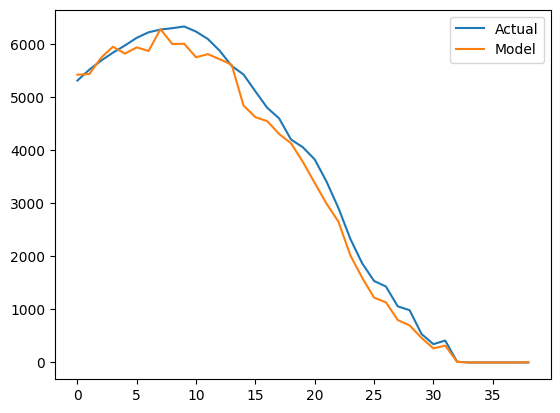

In [23]:
# Apply weights
weights = w_train[w_train.columns[w_train.columns.str.startswith('weight')]].values
y_pred_masked = y_pred * weights

# Weighted average
train_model_mean = y_pred_masked.mean(axis=0) / weights.mean(axis=0)

# Train actual mean
y_vals = y_train.agg('mean').values[2:]
y_vals

train_actual_mean = y_vals / weights.mean(axis=0)

# Quick plot
pd.DataFrame({"Actual": train_actual_mean, "Model": train_model_mean}).plot()

Prediction diagnostics by feature:

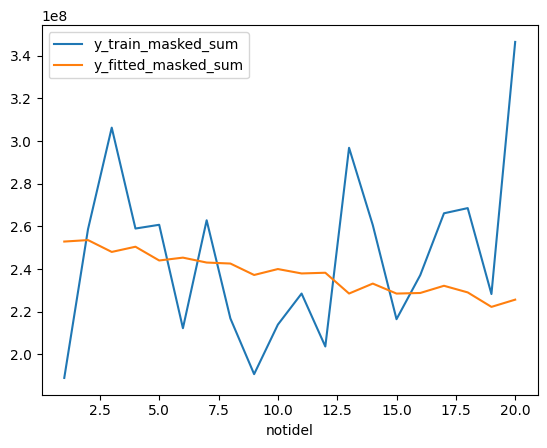

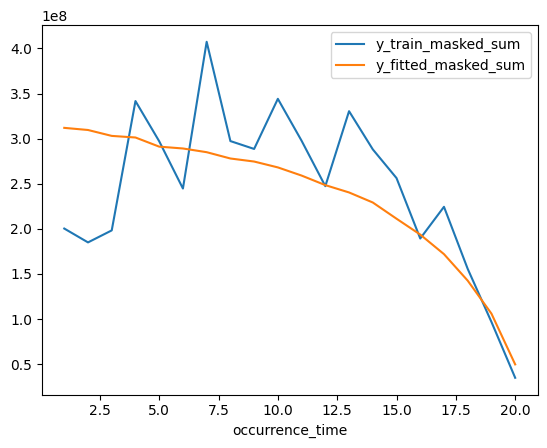

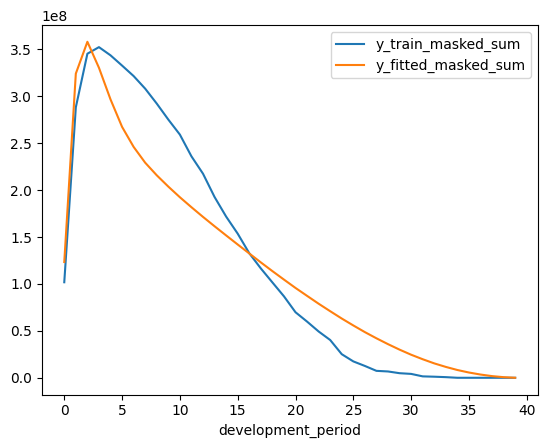

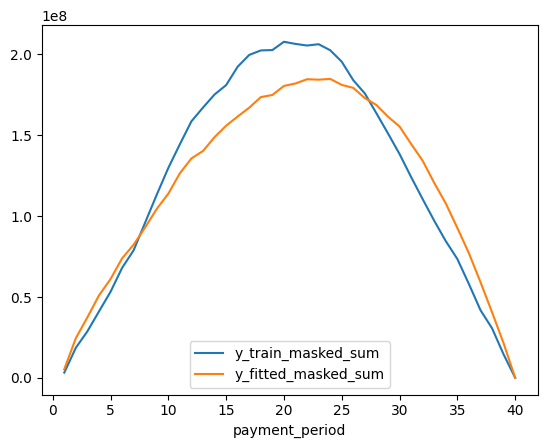

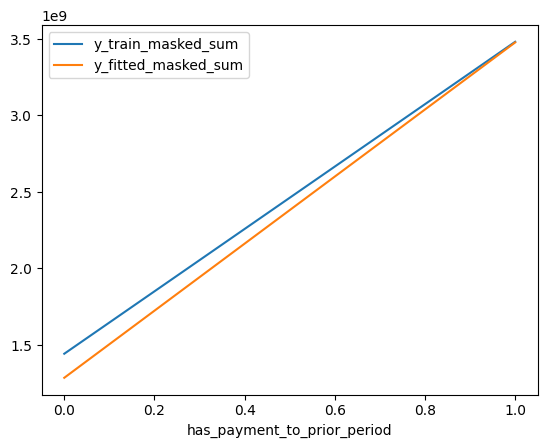

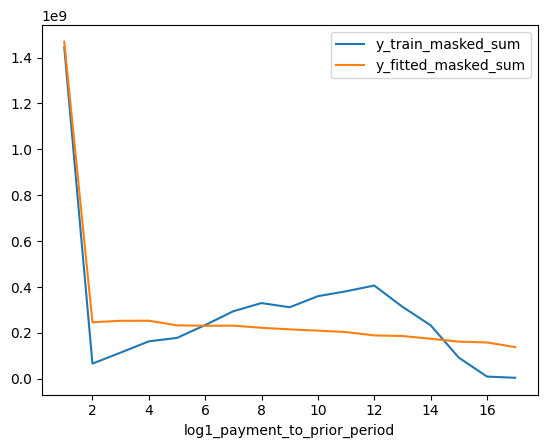

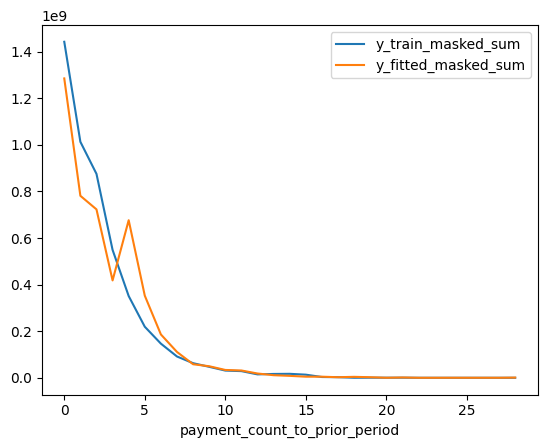

In [24]:
# check totals
dat_train = x_train.assign(
    y_train_masked_sum = y_train.values[:, 2:].sum(axis=1),
    y_fitted_masked_sum = y_pred_masked.sum(axis=1),
)
for f in config["data"].features:
    if dat_train[f].drop_duplicates().shape[0] > 100:
        dat_train[f] = pd.qcut(dat_train[f], 20, labels=False, duplicates='drop') + 1
    dat_train.groupby(f).agg("sum")[["y_train_masked_sum", "y_fitted_masked_sum"]].plot()

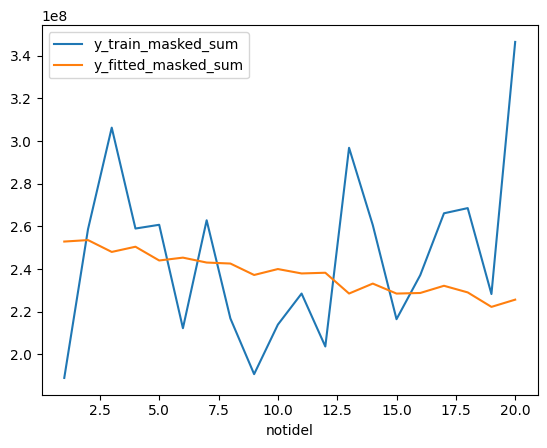

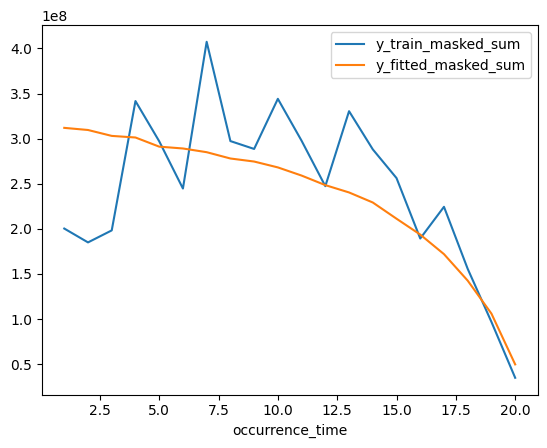

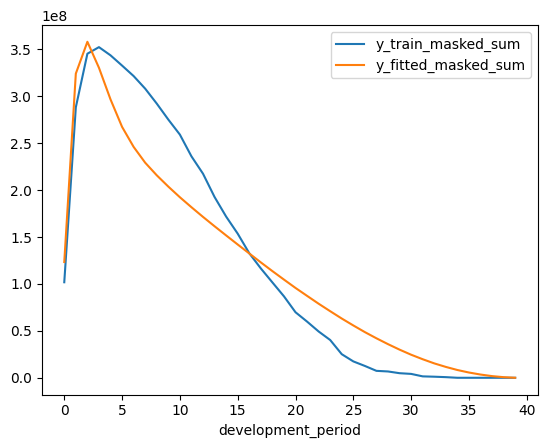

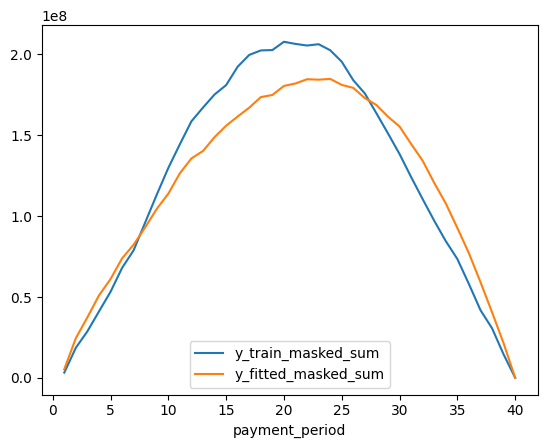

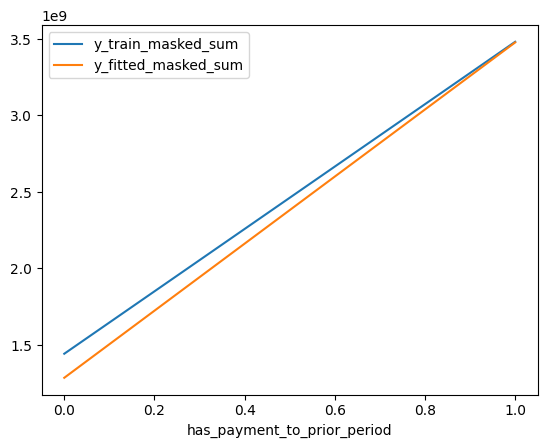

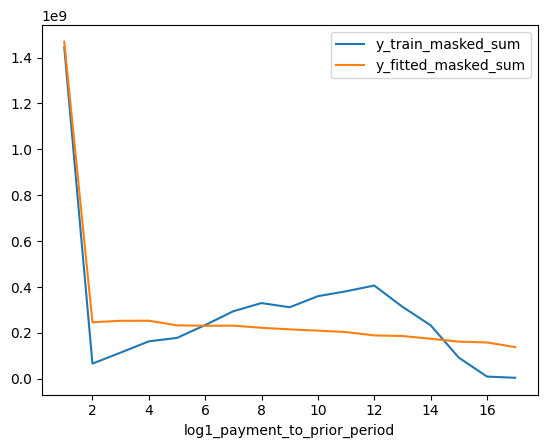

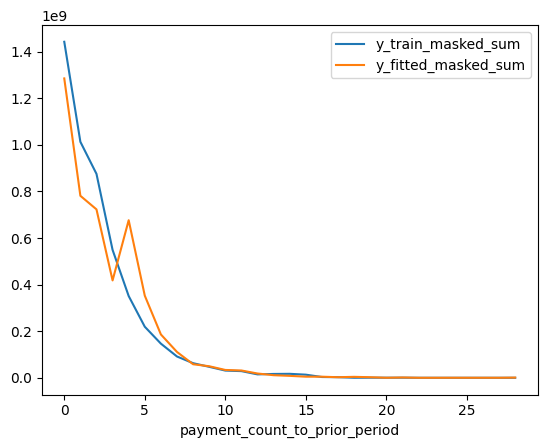

In [25]:
# check totals
dat_train = x_train.assign(
    y_train_masked_sum = y_train.values[:, 2:].sum(axis=1),
    y_fitted_masked_sum = y_pred_masked.sum(axis=1),
)
for f in config["data"].features:
    if dat_train[f].drop_duplicates().shape[0] > 100:
        dat_train[f] = pd.qcut(dat_train[f], 20, labels=False, duplicates='drop') + 1
    dat_train.groupby(f).agg("sum")[["y_train_masked_sum", "y_fitted_masked_sum"]].plot()

## Test Set Evaluation Plots

We create several diagnostic plots to evaluate model performance on test data:
- **Actual vs Expected**: Scatter plots comparing predictions to actual values
- **Logged Plots**: Log-transformed versions for better visualization of large values
- **Ultimate Claims**: Predictions for final claim amounts only

### By subsequent period:

n.b. again, this is not the same as development period.

<Axes: >

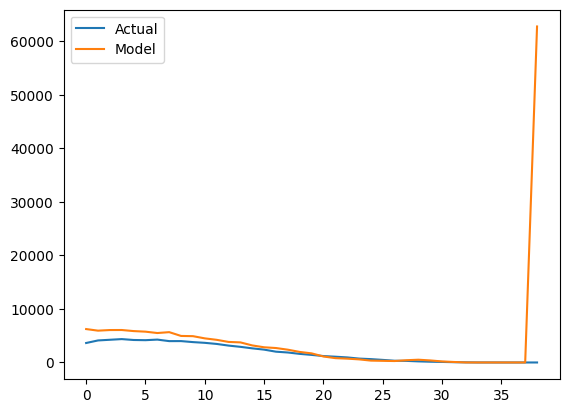

In [26]:
# Quick plot
# Multiply by 1 - train weights, this is the bottom part
expected_test = y_pred * (1 - weights)

actual_test = (
    y_train[["claim_no", "development_period"]]
    .merge(y_test, on=["claim_no", "development_period"], how="left").values[:, 2:] *
    (1 - weights)
)

pd.DataFrame({
    "Actual":  actual_test.sum(axis=0) / (1 - weights).sum(axis=0),
    "Model": expected_test.sum(axis=0) / (1 - weights).sum(axis=0)
}).plot()

In [31]:
pd.DataFrame({
    "Actual":  actual_test.sum(axis=0) / (1 - weights).sum(axis=0),
    "Model": expected_test.sum(axis=0) / (1 - weights).sum(axis=0)
})

,Actual,Model
0,"3,639.67","6,244.61"
1,"4,118.24","5,947.81"
2,"4,244.23","6,061.21"
3,"4,370.48","6,068.46"
4,"4,202.99","5,867.11"
5,"4,167.28","5,759.35"
6,"4,276.24","5,503.97"
7,"3,990.90","5,668.23"
8,"3,996.40","4,959.09"
9,"3,807.88","4,918.66"


Compare actual vs expected by features, including development period:

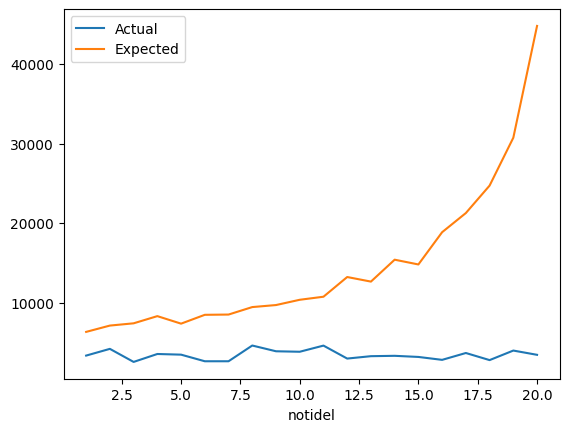

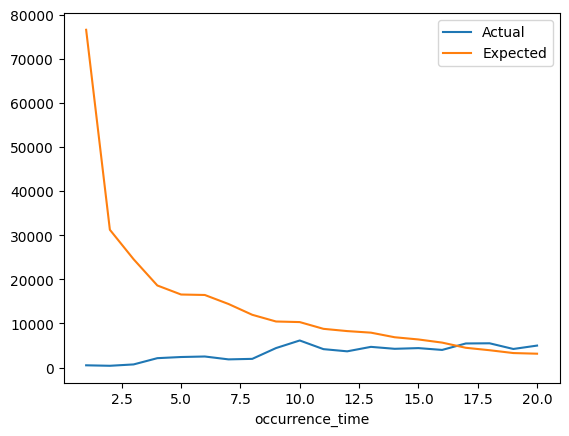

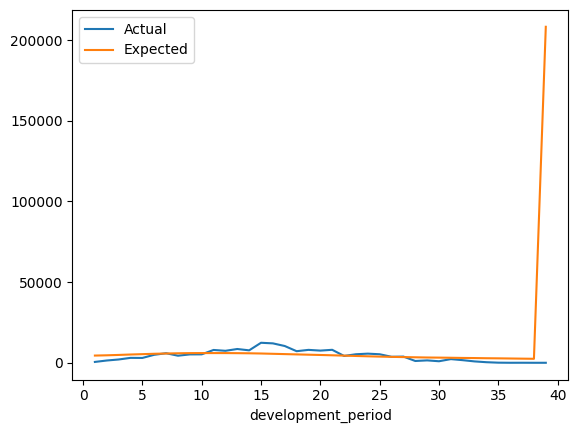

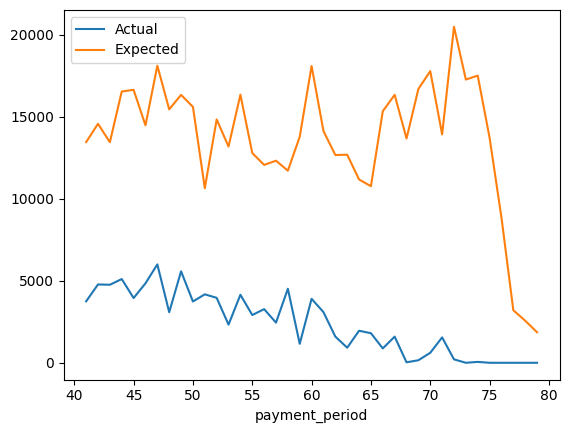

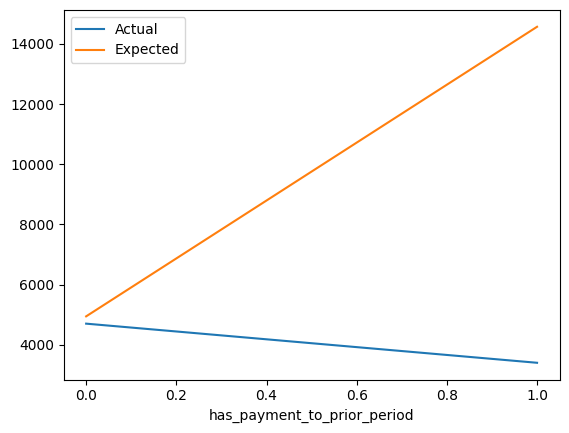

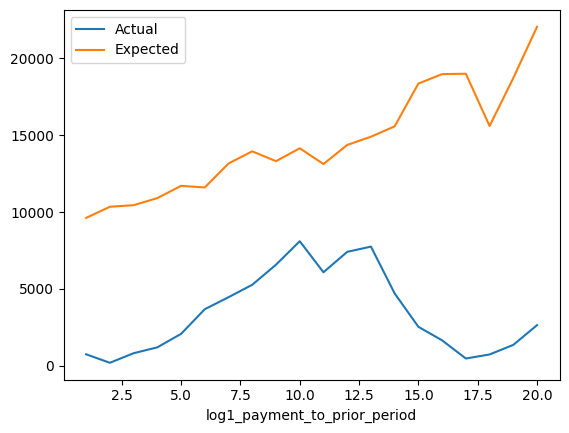

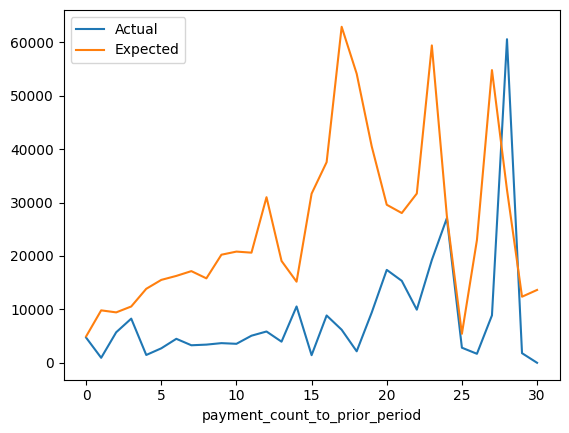

In [27]:
actual_vs_expected_test = pd.merge(
    pred_df,
    dat.loc[
        lambda df: (df.claim_no.isin(pred_df.claim_no.drop_duplicates())) & (~df.train_ind),
        list(dict.fromkeys(["claim_no", "development_period", "payment_period", "payment_size"] + config["data"].features))
    ],
    on=["claim_no", "development_period", "payment_period"]
)

ave = actual_vs_expected_test.copy()
for f in config["data"].features:
    if ave[f].drop_duplicates().shape[0] > 100:
        ave[f] = pd.qcut(ave[f], 20, labels=False, duplicates='drop') + 1
    # Plot average actual and expected amount
    (
        ave[[f, "payment_size", youtput]]
        .rename(columns={
            youtput: "Expected",
            "payment_size": "Actual"
        })
        .groupby(f)
        .agg("mean")
    ).plot()
    plt.show()

In [28]:
actual_vs_expected_test.loc[lambda df: df.development_period == 39]

,claim_no,development_period,predicted_payment_size,payment_period,payment_size,notidel,occurrence_time,has_payment_to_prior_period,log1_payment_to_prior_period,payment_count_to_prior_period
0,104,39,"1,152,704.50",41,0.00,3.84,1.74,1,12.15,5.00
1,105,39,"110,047.62",41,0.00,0.11,1.73,1,4.49,1.00
2,106,39,"194,091.27",41,0.00,0.54,1.89,1,11.94,4.00
3,107,39,"212,026.58",41,0.00,0.56,1.52,1,11.36,6.00
4,108,39,"161,115.06",41,0.00,0.31,1.85,1,10.83,5.00
...,...,...,...,...,...,...,...,...,...,...
66410,3655,39,"3,420.40",79,0.00,0.84,39.14,1,11.68,4.00
66449,3657,39,"2,711.40",79,0.00,0.66,39.22,1,8.71,2.00
66488,3659,39,956.47,79,0.00,0.06,39.54,1,9.89,4.00
66527,3660,39,"1,388.22",79,0.00,0.22,39.43,1,10.53,4.00


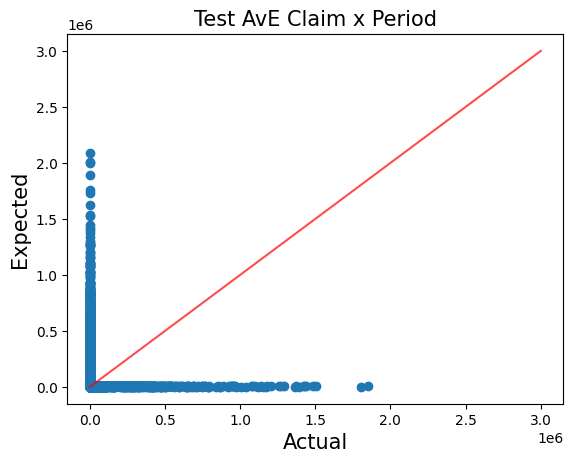

In [29]:
# Actual vs Expected - All Test
fig, ax = create_actual_vs_expected_plot(
    actual_vs_expected_test, "payment_size", youtput, 
    'Test AvE Claim x Period', 
    writer, 'AvsE Test'
)
fig

----------------
# Not updated beyond this point

## Training Set Evaluation Plots

We create several diagnostic plots to evaluate model performance on training data:
- **Actual vs Expected**: Scatter plots comparing predictions to actual values
- **Logged Plots**: Log-transformed versions for better visualization of large values
- **Ultimate Claims**: Predictions for final claim amounts only

In [30]:
# Logged Actual vs Expected - Training
fig, ax = create_actual_vs_expected_plot(
    train_pred, "log_actual", "log_pred_claims", 
    'Logged Train AvsE All History', 
    writer, 'AvsE Logged All Train',
    max_val=20
)

fig

NameError: name 'train_pred' is not defined

In [ ]:
# AvsE Ult - Train
dat_byclaim = train_pred.groupby("claim_no").last()
fig, ax = create_actual_vs_expected_plot(
    dat_byclaim, "claim_size", "pred_claims", 
    'Train AvsE Ult only', 
    writer, 'AvsE Ult only Train'
)

fig

We create several QQ diagnostic plots to evaluate model performance on training data:
- **Actual vs Expected**: Scatter plots comparing predictions to actual values
- **Logged Plots**: Log-transformed versions for better visualization of large values

In [ ]:
train_pred["pred_claims_20cile"] = pd.qcut(train_pred["pred_claims"], 20, labels=False, duplicates='drop')
#X_sum = train_pred.groupby("pred_claims_20cile").agg("mean").reset_index()
#X_sum = train_pred.groupby("pred_claims_20cile")[["payment_size", "pred_claims", "log_actual", "log_pred_claims"]].mean().reset_index()
X_sum = train_pred.groupby("pred_claims_20cile").mean(numeric_only=True).reset_index()

#X_sum = train_pred.groupby("pred_claims_20cile").agg(
#    payment_size_mean=("payment_size","mean"),
#    pred_claims_mean=("pred_claims","mean")
#).reset_index()

# QQ - Train
fig, ax  = create_actual_vs_expected_plot(
    X_sum, "payment_size", "pred_claims", 
    'Train QQ plot 20', 
    writer, 'QQ plot Train'
)
fig


In [ ]:

# Logged QQ - Train
fig, ax  = create_actual_vs_expected_plot(
    X_sum, "log_actual", "log_pred_claims", 
    'Logged Train QQ plot 20', 
    writer, 'QQ plot Logged Train',
    max_val = 20,
)

fig

## Test Set Evaluation Plots

We then repeat the process to create several diagnostic plots to evaluate model performance on test data:
- **Actual vs Expected**: Scatter plots comparing predictions to actual values
- **Logged Plots**: Log-transformed versions for better visualization of large values
- **Ultimate Claims**: Predictions for final claim amounts only

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Create plots TEST
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

test = (dat.loc[(dat.test_ind_time == 1) & (dat.train_ind == 0) & (dat.train_settled == 0)])

youtput="claim_size"
y_pred=model_NN.predict(test)

y_predx=model_NN.predict(x_test)

#merge y_pred back into dat for each claim
claim_nos = test["claim_no"].drop_duplicates()
pred_df = pd.DataFrame({
    "claim_no": claim_nos.values,
    "pred_claims": y_pred
})

if "pred_claims" in test.columns:
    dat = dat.drop(columns=["pred_claims"])

test_pred = test.merge(pred_df, on="claim_no", how="left")

test_pred["log_pred_claims"]=test_pred["pred_claims"].apply(lambda x: np.log(x+1))
test_pred["log_actual"]=test_pred[youtput].apply(lambda x: np.log(x+1))

test_pred["rpt_delay"]=np.ceil(train_pred.notidel).astype(int)

test_pred["diff"]=test_pred[youtput]-train_pred["pred_claims"]
test_pred["diffp"]=(test_pred[youtput]-test_pred["pred_claims"])/test_pred[youtput]

save_df_to_excel(test_pred, df_name="pred_test", filename=log_filename, mode='a')


In [ ]:
# AvsE all - Test
fig, ax = create_actual_vs_expected_plot(
    test_pred, youtput, "pred_claims", 
    'Test AvsE all history', 
    writer, 'AvsE all Test'
)

fig

In [ ]:
# Logged AvsE all - Test
fig, ax = create_actual_vs_expected_plot(
    test_pred, "log_actual", "log_pred_claims", 
    'Logged Test AvsE All History', 
    writer, 'AvsE Logged All Test',
    max_val=20
)

fig

In [ ]:
# AvsE Ult - Test
dat_byclaim = test_pred.groupby("claim_no").last()
fig, ax = create_actual_vs_expected_plot(
    dat_byclaim, "claim_size", "pred_claims", 
    'Test AvsE Ult only', 
    writer, 'AvsE Ult only Test'
)

fig

We create several QQ diagnostic plots to evaluate model performance on test data:
- **Actual vs Expected**: Scatter plots comparing predictions to actual values
- **Logged Plots**: Log-transformed versions for better visualization of large values

In [ ]:
test_pred["pred_claims_20cile"] = pd.qcut(test_pred["pred_claims"], 20, labels=False, duplicates='drop')
#X_sum = test_pred.groupby("pred_claims_20cile").agg("mean").reset_index()
X_sum = test_pred.groupby("pred_claims_20cile").mean(numeric_only=True).reset_index()

# QQ - Test
fig, ax  = create_actual_vs_expected_plot(
    X_sum, "claim_size", "pred_claims", 
    'Test QQ plot 20', 
    writer, 'QQ plot Test'
)

fig


In [ ]:

# Logged QQ - Test
fig, ax  = create_actual_vs_expected_plot(
    X_sum, "log_actual", "log_pred_claims", 
    'Logged Test QQ plot 20', 
    writer, 'QQ plot Logged Test', 
    max_val = 20,
)

fig

## Occurrence Period Plot

We can review the accuracy of the trained model by looking at Actuals and Expected values by Occrrence Period. 

In [ ]:

datTrainUlt=train_pred.groupby("claim_no").last()
datTestUlt=test_pred.groupby("claim_no").last()

datTrain_occ = datTrainUlt.groupby("occurrence_period").agg({youtput: "sum", "pred_claims": "sum"})
datTest_occ = datTestUlt.groupby("occurrence_period").agg({youtput: "sum", "pred_claims": "sum"})

plt.figure()

plt.plot(datTrain_occ.index, datTrain_occ[youtput])
plt.plot(datTrain_occ.index, datTrain_occ.pred_claims)

plt.plot(datTest_occ.index, datTest_occ[youtput])
plt.plot(datTest_occ.index, datTest_occ.pred_claims)

fig, ax = plt.subplots()
ax.plot(datTrain_occ.index, datTrain_occ[youtput], linestyle='--', label='Train Actual')
ax.plot(datTrain_occ.index, datTrain_occ.pred_claims, linestyle='--', label='Train Expected')
ax.plot(datTest_occ.index, datTest_occ[youtput], label='Test Actual')
ax.plot(datTest_occ.index, datTest_occ.pred_claims, label='Test Expected')
ax.set_yscale("log") 
ax.set_xlabel('Occurrence period', fontsize=15)
ax.set_ylabel('Total Ultimate claims', fontsize=15)
ax.set_title('by Occurrence Period')     
ax.legend()
writer.add_figure('by Occur Period', fig)


fig


# Development date plots


In [ ]:
datTrain_dev = train_pred.groupby("development_period").agg({youtput: "sum", "pred_claims": "sum"})
datTest_dev = test_pred.groupby("development_period").agg({youtput: "sum", "pred_claims": "sum"})

plt.figure()

plt.plot(datTrain_dev.index, datTrain_dev[youtput])
plt.plot(datTrain_dev.index, datTrain_dev.pred_claims)

plt.plot(datTest_dev.index, datTest_dev[youtput])
plt.plot(datTest_dev.index, datTest_dev.pred_claims)


fig, ax = plt.subplots()
ax.plot(datTrain_dev.index, datTrain_dev[youtput], linestyle='--', label='Train Actual')
ax.plot(datTrain_dev.index, datTrain_dev.pred_claims, linestyle='--', label='Train Expected')
ax.plot(datTest_dev.index, datTest_dev[youtput], label='Test Actual')
ax.plot(datTest_dev.index, datTest_dev.pred_claims, label='Test Expected')
ax.set_xlabel('Development period', fontsize=15)
ax.set_ylabel('Total claims', fontsize=15)
ax.set_title('by Devevelopment Period')     
ax.legend()
writer.add_figure('by Dev Period', fig)

fig

## Development Period Plot

We can review the accuracy of the trained model by looking at Actuals and Expected values by Development Period. 

In [ ]:
datTrain_dev = train_pred.groupby("development_period").agg({youtput: "sum", "pred_claims": "sum"})
datTest_dev = test_pred.groupby("development_period").agg({youtput: "sum", "pred_claims": "sum"})

plt.figure()

plt.plot(datTrain_dev.index, datTrain_dev[youtput])
plt.plot(datTrain_dev.index, datTrain_dev.pred_claims)

plt.plot(datTest_dev.index, datTest_dev[youtput])
plt.plot(datTest_dev.index, datTest_dev.pred_claims)


fig, ax = plt.subplots()
ax.plot(datTrain_dev.index, datTrain_dev[youtput], linestyle='--', label='Train Actual')
ax.plot(datTrain_dev.index, datTrain_dev.pred_claims, linestyle='--', label='Train Expected')
ax.plot(datTest_dev.index, datTest_dev[youtput], label='Test Actual')
ax.plot(datTest_dev.index, datTest_dev.pred_claims, label='Test Expected')
ax.set_xlabel('Development period', fontsize=15)
ax.set_ylabel('Total claims', fontsize=15)
ax.set_title('by Devevelopment Period')     
ax.legend()
writer.add_figure('by Dev Period', fig)

fig